### 1. Подготовка к текстам

#### 1.1 Зависимости модификация классов для вычисления времени работы и вспомогательная функция

In [6]:
import numpy as np
import pandas as pd
import os, time
from tqdm.notebook import tqdm
from game_generator import generate_game
from CoreFinder import CoreFinder, CoreFinderOpt, CoreFinderAlt
from other_alghorits import min_sum_core_point, shapley_value, nucleolus

class Excess(CoreFinder):  
    def __init__(self, n = None, v = None, precision = 10, eps = 10):
            self._add_n(n)
            self._add_v(v)
            self.precision = precision
            self.eps = 10 ** (-eps)
            self.x = {}
            self.imputation = None

class TCoreFinder(CoreFinder):  
    def _run(self):
        t0 = time.time()
        super()._run()
        self.dt = time.time() - t0

    def __init__(self, n: list = None, v: dict = None, precision: int = 10, eps: int = 10):
        super().__init__(n, v, precision, eps)


class TCoreFinderOpt(CoreFinderOpt):
    def _run(self):
        t0 = time.time()
        super()._run()
        self.dt = time.time() - t0

    def __init__(self, n: list = None, v: dict = None, precision: int = 10, eps: int = 10):
        super().__init__(n, v, precision, eps)
    
    
class TCoreFinderAlt(CoreFinderAlt):
    def _run(self):
        t0 = time.time()
        super()._run()
        self.dt = time.time() - t0

    def __init__(self, n: list = None, v: dict = None, early_stop = True, precision: int = 10, eps: int = 10):
        super().__init__(n, v, early_stop, precision, eps)

def v_to_dict(v: np.ndarray, n: int) -> dict:
    result = {}
    for mask in range(1, 1 << n):
        coalition = frozenset(i + 1 for i in range(n) if (mask >> i) & 1)
        result[coalition] = float(v[mask])
    return result

#### 1.2 Функция для генерации игр

In [7]:
def pregenerate_games(game_type: str,
                      n: int,
                      total: int,
                      path: str = 'local\\results'):
    """
    Генерирует игры

    Параметры
    ---------
    game_type   : 'Balanced' | 'Superadditive'
    n           : количество игроков
    total       : количество игр для тестирования
    path        : путь для сохранения файлов (по умолчанию 'local\\results')

    Сохраняет игры в формате '{path}\\pregenerate_games\\{game_type}\\{n}\\{seed}_{время_гененерации}.parquet'
    """
    
    games_path = f'{path}\\pregenerate_games\\{game_type}\\{n}'

    os.makedirs(games_path, exist_ok=True)  

    seeds = [int(f.split('_')[0]) for f in os.listdir(games_path)]
    seeds = [i for i in range(total) if not i in seeds]
    

    for seed in tqdm(seeds):
        rng = np.random.default_rng(seed)

        match game_type:
            case 'Balanced':
                game = generate_game(n, rng=rng)
            case 'Superadditive':
                game = generate_game(n, superadditive=True, rng=rng)
            case _:
                raise ValueError(f"Unknown game type: {game_type}")

        t0 = time.time()
        game[(1<<n)-1] = float(sum(min_sum_core_point(n, game)))
        dt = time.time() - t0
        pd.DataFrame(game, columns=['value']
                     ).to_parquet(f'{games_path}\\{seed}_{dt}.parquet', index=False)

#### 1.3 Функция для тестов алгоритмов

In [8]:
def precompute(game_type: str,
               n: int,
               total: int,
               Shapley: bool = False,
               CF: bool = False,
               CFO: bool = False,
               CFA: bool = False,
               path: str = 'local\\results'):
    """
    Проводит тесты алгоритмов на сгенерированных играх

    Параметры
    ---------
    game_type : 'Balanced' | 'Superadditive'
    n         : количество игроков
    total     : количество игр для тестирования
    Shapley   : вычислять ли вектор Шепли
    CF        : вычислять ли базовый алгоритм
    CFO       : вычислять ли оптимизированный алгоритм
    CFA       : вычислять ли альтернативный алгоритм
    path      : путь для сохранения файлов (по умолчанию 'local\\results')

    Сохраняет результаты в формате '{path}\\precompute\\{game_type}\\{n}\\{seed}\\{name}.xlsx',
    где name: 'Shapley' | 'CF' | 'CFO' | 'CFA'
    """
    
    games_path = f'{path}\\pregenerate_games\\{game_type}\\{n}'
    precompute_path = f'{path}\\precompute\\{game_type}\\{n}'


    # проверка достаточного количества игр
    os.makedirs(games_path, exist_ok=True)
    os.makedirs(precompute_path, exist_ok=True)
    game_seeds = {int(f.split('_')[0]): f for f in os.listdir(games_path)}
    game_seeds = {i: game_seeds[i] for i in game_seeds if i in range(total)}

    for seed in tqdm(game_seeds):

        shapley_flag = False
        if not os.path.exists(f'{precompute_path}\\{seed}\\Shapley.xlsx') and Shapley:
            os.makedirs(f'{precompute_path}\\{seed}', exist_ok=True)
            shapley_flag = True

        cf_flag = False
        if not os.path.exists(f'{precompute_path}\\{seed}\\CF.xlsx') and CF:
            os.makedirs(f'{precompute_path}\\{seed}', exist_ok=True)
            cf_flag = True

        cfo_flag = False
        if not os.path.exists(f'{precompute_path}\\{seed}\\CFO.xlsx') and CFO:
            os.makedirs(f'{precompute_path}\\{seed}', exist_ok=True)
            cfo_flag = True

        cfa_flag = False
        if not os.path.exists(f'{precompute_path}\\{seed}\\CFA.xlsx') and CFA:
            os.makedirs(f'{precompute_path}\\{seed}', exist_ok=True)
            cfa_flag = True

        if shapley_flag or cf_flag or cfo_flag or cfa_flag:

            game = pd.read_parquet(f'{games_path}\\{game_seeds[seed]}'
                                )["value"].to_numpy()
            v_n = game[(1<<n)-1]

            if shapley_flag:
                t0 = time.time()
                x = shapley_value(n, game)
                dt = time.time() - t0
                x = pd.DataFrame(x, columns=['x'])
                details = pd.DataFrame([{
                    'dt': dt,
                }])

                with pd.ExcelWriter(f'{precompute_path}\\{seed}\\Shapley.xlsx', engine='openpyxl') as writer:
                    x.to_excel(writer, sheet_name='x', index=False)
                    details.to_excel(writer, sheet_name='details', index=False)
            
            game = v_to_dict(game, n)

            if cf_flag:
                cf = TCoreFinder(n, game)
                x = pd.DataFrame(cf.x.values(), columns=['x'])
                details = pd.DataFrame([{
                    'x_N': cf.x_N,
                    'dt': cf.dt,
                    'dif': (cf.x_N - v_n) / v_n
                }])

                with pd.ExcelWriter(f'{precompute_path}\\{seed}\\CF.xlsx', engine='openpyxl') as writer:
                    x.to_excel(writer, sheet_name='x', index=False)
                    details.to_excel(writer, sheet_name='details', index=False)

            if cfo_flag:
                cf = TCoreFinderOpt(n, game)
                x = pd.DataFrame(cf.x.values(), columns=['x'])
                details = pd.DataFrame([{
                    'x_N': cf.x_N,
                    'dt': cf.dt,
                    'dif': (cf.x_N - v_n) / v_n
                }])

                with pd.ExcelWriter(f'{precompute_path}\\{seed}\\CFO.xlsx', engine='openpyxl') as writer:
                    x.to_excel(writer, sheet_name='x', index=False)
                    details.to_excel(writer, sheet_name='details', index=False)
  
            if cfa_flag:
                cf = TCoreFinderAlt(n, game)

                x = pd.DataFrame(cf.x.values(), columns=['x'])
                details = pd.DataFrame([{
                    'x_N': cf.x_N,
                    'dt': cf.dt,
                    'dif': (cf.x_N - v_n) / v_n
                }])

                with pd.ExcelWriter(f'{precompute_path}\\{seed}\\CFA.xlsx', engine='openpyxl') as writer:
                    x.to_excel(writer, sheet_name='x', index=False)
                    details.to_excel(writer, sheet_name='details', index=False)


#### 1.4 Функция для сбора результатов

In [9]:
def compute(game_type: str,
            n: int,
            total: int,
            coefficient: float = None,
            path: str = 'local\\results'):
    """
    Собирает все результаты в один файл для единого коэффициента, типа и размера игры

    Параметры
    ---------
    game_type   : 'Balanced' | 'Superadditive'
    n           : количество игроков
    total       : количество игр для тестирования
    coefficient : коэффициент, выполняющий функцию матожидания для дельты (по умолчанию 1 / n)
    path        : путь для сохранения файлов (по умолчанию 'local\\results')

    Сохраняет результаты в формате '{path}\\compute\\{game_type}\\{seed}\\{n}\\{coefficient}.xlsx'
    """
    games_path = f'{path}\\pregenerate_games\\{game_type}\\{n}'
    precompute_path = f'{path}\\precompute\\{game_type}\\{n}'
    compute_path = f'{path}\\compute\\{game_type}\\{n}'

    if coefficient == None:
        coefficient = 1 / n

    try:
        dfs = pd.read_excel(f'{compute_path}\\{coefficient}.xlsx', sheet_name=None, index_col=0)
        table = dfs['table'].to_dict()
        series = dfs['series'].iloc[0].to_dict()

        table = {
            k: {ik: iv for ik, iv in v.items() if pd.notna(iv)}
            for k, v in table.items()
        }
    except Exception:
        if os.path.exists(f'{compute_path}\\{coefficient}.xlsx'):
            raise Exception(f'Повреждён файл: {compute_path}\\{coefficient}.xlsx')
        
        table = {
            'exc_dt': {},
            'mscp_dt': {},
            'shapley_dt': {},
            'cf_dt': {},
            'cfo_dt': {},
            'cfa_dt': {},

            'mscp_dif': {},
            'cf_dif': {},
            'cfo_dif': {},
            'cfa_dif': {}
            }
        series = {
            'shapley_core_hits': 0,
            'cf_core_hits': 0,
            'cfo_core_hits': 0,
            'cfa_core_hits': 0,

            'cf_vn_hits': 0,
            'cfo_vn_hits': 0,
            'cfa_vn_hits': 0,

            'shapley_count': 0,
            'cf_count': 0,
            'cfo_count': 0,
            'cfa_count': 0
            }

    # проверка достаточного количества игр
    os.makedirs(games_path, exist_ok=True)
    os.makedirs(compute_path, exist_ok=True)  
    game_seeds = {int(f.split('_')[0]): f for f in os.listdir(games_path)}
    game_seeds = {i: game_seeds[i] for i in game_seeds if i in range(total)}

    for seed in tqdm(game_seeds):

        shapley_flag = False
        if os.path.exists(f'{precompute_path}\\{seed}\\Shapley.xlsx') and not seed in table['shapley_dt']:
            shapley_flag = True
        
        cf_flag = False
        if os.path.exists(f'{precompute_path}\\{seed}\\CF.xlsx') and not seed in table['cf_dt']:
            cf_flag = True
        
        cfo_flag = False
        if os.path.exists(f'{precompute_path}\\{seed}\\CFO.xlsx') and not seed in table['cfo_dt']:
            cfo_flag = True
        
        cfa_flag = False
        if os.path.exists(f'{precompute_path}\\{seed}\\CFA.xlsx') and not seed in table['cfa_dt']:
            cfa_flag = True

        if shapley_flag or cf_flag or cfo_flag or cfa_flag:

            game = pd.read_parquet(f'{games_path}\\{game_seeds[seed]}'
                            )["value"].to_numpy().copy()
            
            min_vn = game[(1<<n)-1]
            game_delta =  coefficient * (np.random.default_rng(seed).random() * 2) * min_vn
            v_n = min_vn + game_delta
            game[(1<<n)-1] = v_n
            game = v_to_dict(game, n)
            exc = Excess(n, game)
            
            exc_dt = []

            if shapley_flag:
                series['shapley_count'] += 1

                df = pd.read_excel(f'{precompute_path}\\{seed}\\Shapley.xlsx', sheet_name=None)
                x = df["x"].iloc[:, 0].tolist()
                delta = (v_n - sum(x)) / n
                x = [i + delta for i in x]
                table['shapley_dt'][seed] = df["details"].iloc[0]['dt']
                
                to = time.time()
                if exc.check_excess(check = x)["in_core"]:
                    series['shapley_core_hits'] += 1
                exc_dt += [time.time() - to]

            
            if cf_flag:
                series['cf_count'] += 1

                df = pd.read_excel(f'{precompute_path}\\{seed}\\CF.xlsx', sheet_name=None)
                x = df["x"].iloc[:, 0].tolist()
                details = df["details"].iloc[0]

                table['cf_dt'][seed] = details['dt']
                table['cf_dif'][seed] = details['dif']
                
                delta = (v_n - sum(x)) / n
                x = [i + delta for i in x]
                to = time.time()
                if exc.check_excess(check = x)["in_core"]:
                    series['cf_core_hits'] += 1
                exc_dt += [time.time() - to]

                if details['x_N'] <= v_n + 1e-6:
                    series['cf_vn_hits'] += 1
            
            if cfo_flag:
                series['cfo_count'] += 1

                df = pd.read_excel(f'{precompute_path}\\{seed}\\CFO.xlsx', sheet_name=None)
                x = df["x"].iloc[:, 0].tolist()
                details = df["details"].iloc[0]

                table['cfo_dt'][seed] = details['dt']
                table['cfo_dif'][seed] = details['dif']

                delta = (v_n - sum(x)) / n
                x = [i + delta for i in x]
                to = time.time()
                if exc.check_excess(check = x)["in_core"]:
                    series['cfo_core_hits'] += 1
                exc_dt += [time.time() - to]

                if details['x_N'] <= v_n + 1e-6:
                    series['cfo_vn_hits'] += 1

            if cfa_flag:
                series['cfa_count'] += 1

                df = pd.read_excel(f'{precompute_path}\\{seed}\\CFA.xlsx', sheet_name=None)
                x = df["x"].iloc[:, 0].tolist()
                details = df["details"].iloc[0]

                table['cfa_dt'][seed] = details['dt']
                table['cfa_dif'][seed] = details['dif']
                
                delta = (v_n - sum(x)) / n
                x = [i + delta for i in x]
                to = time.time()
                if exc.check_excess(check = x)["in_core"]:
                    series['cfa_core_hits'] += 1
                exc_dt += [time.time() - to]

                if details['x_N'] <= v_n + 1e-6:
                    series['cfa_vn_hits'] += 1

            if not seed in table['mscp_dt']:
                table['mscp_dt'][seed] = float(game_seeds[seed].split('_')[1].replace(".parquet", ''))
                table['mscp_dif'][seed] = game_delta / min_vn            
                table['exc_dt'][seed] = np.mean(exc_dt)

                


            with pd.ExcelWriter(f'{compute_path}\\{coefficient}.xlsx', engine='openpyxl') as writer:
                pd.DataFrame(table).to_excel(writer, sheet_name='table')
                pd.DataFrame([series]).to_excel(writer, sheet_name='series', index=False)


#### 1.5 Функция для вычисления расстояний между решениями

In [10]:
def compute_distance(game_type: str,
                     n: int,
                     total: int,
                     coefficient: float = None,
                     nucleolus_flag: bool = True,
                     path: str = 'local\\results'
                     ):
    """
    Вычисляет расстояние между решениями алгоритмов, вектора Шепли и N-ядра

    Параметры
    ---------
    game_type      : 'Balanced' | 'Superadditive'
    n              : количество игроков
    total          : количество игр для тестирования
    coefficient    : коэффициент, выполняющий функцию матожидания для дельты (по умолчанию 1 / n)
    nucleolus_flag : вычислять ли N-ядро (по умолчанию True)
    path           : путь для сохранения файлов (по умолчанию 'local\\results')

    Сохраняет результаты в формате '{path}\\compute\\{game_type}\\{seed}\\{n}\\{coefficient}.xlsx'
    """
    games_path = f'{path}\\pregenerate_games\\{game_type}\\{n}'
    precompute_path = f'{path}\\precompute\\{game_type}\\{n}'
    save_path = f'{path}\\compute_distance\\{game_type}\\{n}'

    def distance(x, y):
        return np.sqrt(sum([(x[i] - y[i]) ** 2 for i in range(len(x))]))


    if coefficient == None:
        coefficient = 1 / n

    try:
        dfs = pd.read_excel(f'{save_path}\\{coefficient}.xlsx', sheet_name=None, index_col=0)
        table = dfs['table'].to_dict()

        table = {
            k: {ik: iv for ik, iv in v.items() if pd.notna(iv)}
            for k, v in table.items()
        }
    except Exception:
        if os.path.exists(f'{save_path}\\{coefficient}.xlsx'):
            os.remove(f'{save_path}\\{coefficient}.xlsx')
            time.sleep(0.5)
        
        table = {
            'nuc_dt': {},

            'nuc_vs_shapley': {},
            'nuc_vs_cf': {},
            'nuc_vs_cfo': {},
            'nuc_vs_cfa': {},

            'shapley_vs_cf': {},
            'shapley_vs_cfo': {},
            'shapley_vs_cfa': {},
            }


    # проверка достаточного количества игр
    os.makedirs(games_path, exist_ok=True)
    os.makedirs(save_path, exist_ok=True)  
    game_seeds = {int(f.split('_')[0]): f for f in os.listdir(games_path)}
    game_seeds = {i: game_seeds[i] for i in game_seeds if i in range(total)}

    for seed in tqdm(game_seeds):

        if nucleolus_flag:

            nuc_vs_shapley = False
            if os.path.exists(f'{precompute_path}\\{seed}\\Shapley.xlsx') and not seed in table['nuc_vs_shapley']:
                nuc_vs_shapley = True

            nuc_vs_cf = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CF.xlsx') and not seed in table['nuc_vs_cf']:
                nuc_vs_cf = True

            nuc_vs_cfo = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CFO.xlsx') and not seed in table['nuc_vs_cfo']:
                nuc_vs_cfo = True

            nuc_vs_cfa = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CFA.xlsx') and not seed in table['nuc_vs_cfa']:
                nuc_vs_cfa = True

        if os.path.exists(f'{precompute_path}\\{seed}\\Shapley.xlsx'):

            shapley_vs_cf = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CF.xlsx') and not seed in table['shapley_vs_cf']:
                shapley_vs_cf = True

            shapley_vs_cfo = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CFO.xlsx') and not seed in table['shapley_vs_cfo']:
                shapley_vs_cfo = True

            shapley_vs_cfa = False
            if os.path.exists(f'{precompute_path}\\{seed}\\CFA.xlsx') and not seed in table['shapley_vs_cfa']:
                shapley_vs_cfa = True


        
        if nuc_vs_shapley or shapley_vs_cf or shapley_vs_cfo or shapley_vs_cfa:
             shapley_x = pd.read_excel(f'{precompute_path}\\{seed}\\Shapley.xlsx', sheet_name=None)["x"].iloc[:, 0].tolist()

        if nuc_vs_shapley or nuc_vs_cf or nuc_vs_cfo or nuc_vs_cfa:

            game = pd.read_parquet(f'{games_path}\\{game_seeds[seed]}'
                            )["value"].to_numpy().copy()
            
            min_vn = game[(1<<n)-1]
            game_delta =  coefficient * (np.random.default_rng(seed).random() * 2) * min_vn
            v_n = min_vn + game_delta
            game[(1<<n)-1] = v_n

            t0 = time.time()
            nuc_x = nucleolus(game, n)
            table['nuc_dt'][seed] = time.time() - t0
            
        else:
            if shapley_vs_cf or shapley_vs_cfo or shapley_vs_cfa:
                min_vn = sum(shapley_x)
                game_delta = coefficient * (np.random.default_rng(seed).random() * 2) * v_n
                vn = min_vn + game_delta
        
        if nuc_vs_shapley or shapley_vs_cf or shapley_vs_cfo or shapley_vs_cfa:
            delta = game_delta / n
            shapley_x = [i + delta for i in shapley_x]
        
        if nuc_vs_cf or shapley_vs_cf:
            cf_x = pd.read_excel(f'{precompute_path}\\{seed}\\CF.xlsx', sheet_name=None)["x"].iloc[:, 0].tolist()
            delta = (v_n - sum(cf_x)) / n
            cf_x = [i + delta for i in cf_x]

        if nuc_vs_cfo or shapley_vs_cfo:
            cfo_x = pd.read_excel(f'{precompute_path}\\{seed}\\CFO.xlsx', sheet_name=None)["x"].iloc[:, 0].tolist()
            delta = (v_n - sum(cfo_x)) / n
            cfo_x = [i + delta for i in cfo_x]

        if nuc_vs_cfa or shapley_vs_cfa:
            cfa_x = pd.read_excel(f'{precompute_path}\\{seed}\\CFA.xlsx', sheet_name=None)["x"].iloc[:, 0].tolist()
            delta = (v_n - sum(cfa_x)) / n
            cfa_x = [i + delta for i in cfa_x]
        
        if nuc_vs_shapley:
             table["nuc_vs_shapley"][seed] = distance(nuc_x, shapley_x) / v_n

        if nuc_vs_cf:
             table["nuc_vs_cf"][seed] = distance(nuc_x, cf_x) / v_n

        if nuc_vs_cfo:
             table["nuc_vs_cfo"][seed] = distance(nuc_x, cfo_x) / v_n

        if nuc_vs_cfa:
             table["nuc_vs_cfa"][seed] = distance(nuc_x, cfa_x) / v_n

        if shapley_vs_cf:
             table["shapley_vs_cf"][seed] = distance(shapley_x, cf_x) / v_n

        if shapley_vs_cfo:
             table["shapley_vs_cfo"][seed] = distance(shapley_x, cfo_x) / v_n

        if shapley_vs_cfa:
             table["shapley_vs_cfa"][seed] = distance(shapley_x, cfa_x) / v_n
        
        if nuc_vs_shapley or nuc_vs_cf or nuc_vs_cfo or nuc_vs_cfa or shapley_vs_cf or shapley_vs_cfo or shapley_vs_cfa:
            with pd.ExcelWriter(f'{save_path}\\{coefficient}.xlsx', engine='openpyxl') as writer:
                pd.DataFrame(table).to_excel(writer, sheet_name='table')

### 2. Тесты

Генерация игр

In [ ]:
for n in range(3, 21):
    pregenerate_games('Balanced', n, 1000)

for n in range(3, 17):
    pregenerate_games('Superadditive', n, 1000)

for n in range(17, 19):
    pregenerate_games('Superadditive', n, 100)

for n in range(19, 21):
    pregenerate_games('Superadditive', n, 10)

Тесты на сгенерированных играх

In [ ]:
for n in range(3, 11):
    precompute('Balanced', n, 1000, True, True, True, True)
    precompute('Superadditive', n, 1000, True, True, True, True)

for n in range(11, 21):
    precompute('Balanced', n, 1000, True, True, True)
    precompute('Superadditive', n, 1000, True, True, True)

for n in range(11, 16):
    precompute('Balanced', n, 10, CFA = True)
    precompute('Superadditive', n, 10, CFA = True)

Сбор результатов

In [ ]:
for n in range(3, 21):
    compute('Balanced', n, 1000)
    compute('Superadditive', n, 1000)
    
    compute('Balanced', n, 1000, coefficient = 1/np.sqrt(n))
    compute('Superadditive', n, 1000, coefficient = 1/n**2)

Вычисление расстояний между различныфми решениями

In [ ]:
for n in range(3, 16):
    compute_distance('Balanced', n, 1000)
    compute_distance('Superadditive', n, 1000)

### 3. Графики

#### 3.1 Стандартные коэффициенты и расстояния между решениями

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

def add_row(table_list, n, coefficient, compute_path, distance_path = False):
    try:
        with np.errstate(divide='ignore', invalid='ignore'):
            table = pd.read_excel(f'{compute_path}\\{coefficient}.xlsx', sheet_name='table', index_col=0)
            series = pd.read_excel(f'{compute_path}\\{coefficient}.xlsx', sheet_name='series').iloc[0]

            table_list[n] = {
                'exc_dt': table['exc_dt'].mean(),
                'mscp_dt': table['mscp_dt'].mean(),
                'shapley_dt': table['shapley_dt'].mean(),
                'cf_dt': table['cf_dt'].mean(),
                'cfo_dt': table['cfo_dt'].mean(),
                'cfa_dt': table['cfa_dt'].mean(),

                'mscp_dif': table['mscp_dif'].mean() * 100,
                'cf_dif': table['cf_dif'].mean() * 100,
                'cfo_dif': table['cfo_dif'].mean() * 100,
                'cfa_dif': table['cfa_dif'].mean() * 100,

                'shapley_core_hits': series['shapley_core_hits'] / series['shapley_count'] * 100,
                'cf_core_hits': series['cf_core_hits'] / series['cf_count'] * 100,
                'cfo_core_hits': series['cfo_core_hits'] / series['cfo_count'] * 100,
                'cfa_core_hits': series['cfa_core_hits'] / series['cfa_count'] * 100,

                'cf_vn_hits': series['cf_vn_hits'] / series['cf_count'] * 100,
                'cfo_vn_hits': series['cfo_vn_hits'] / series['cfo_count'] * 100,
                'cfa_vn_hits': series['cfa_vn_hits'] / series['cfa_count'] * 100,
            }

    except Exception:
        if os.path.exists(f'{compute_path}\\{coefficient}.xlsx'):
            raise Exception(f'Повреждён файл: {compute_path}\\{coefficient}.xlsx')
        
    if distance_path:
        try:
            with np.errstate(divide='ignore', invalid='ignore'):
                table = pd.read_excel(f'{distance_path}\\{coefficient}.xlsx', sheet_name='table', index_col=0)

                table_list[n].update({
                    'nuc_dt': table['nuc_dt'].mean(),

                    'nuc_vs_shapley': table['nuc_vs_shapley'].mean() * 100,
                    'nuc_vs_cf': table['nuc_vs_cf'].mean() * 100,
                    'nuc_vs_cfo': table['nuc_vs_cfo'].mean() * 100,
                    'nuc_vs_cfa': table['nuc_vs_cfa'].mean() * 100,

                    'shapley_vs_cf': table['shapley_vs_cf'].mean() * 100,
                    'shapley_vs_cfo': table['shapley_vs_cfo'].mean() * 100,
                    'shapley_vs_cfa': table['shapley_vs_cfa'].mean() * 100,
                })

        except Exception:
            if os.path.exists(f'{distance_path}\\{coefficient}.xlsx'):
                raise Exception(f'Повреждён файл: {distance_path}\\{coefficient}.xlsx')

##### 3.1.1 Случайные игры

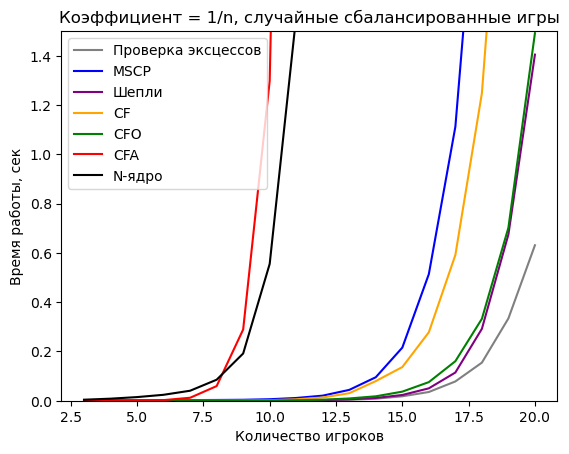

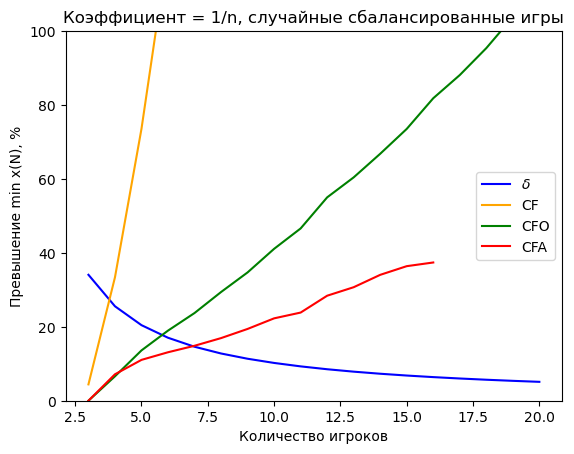

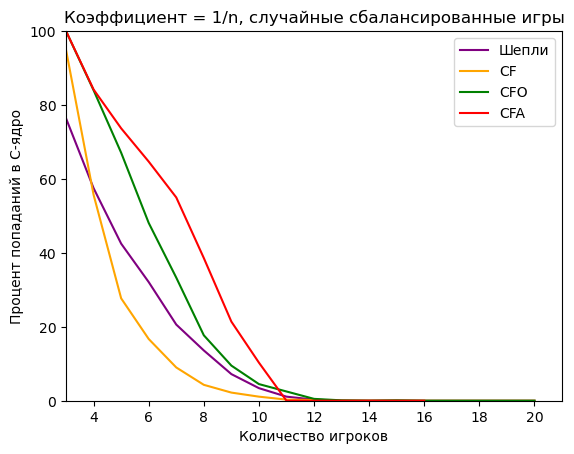

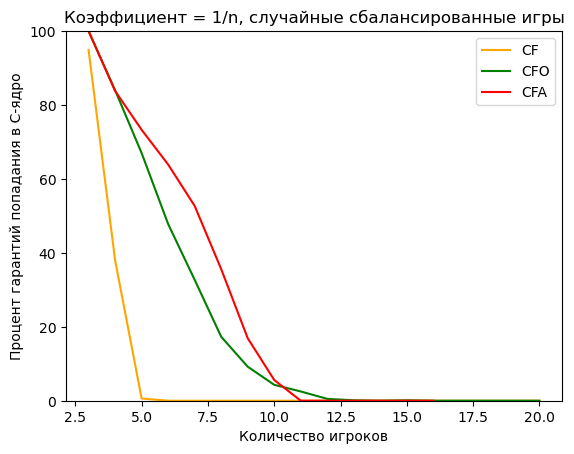

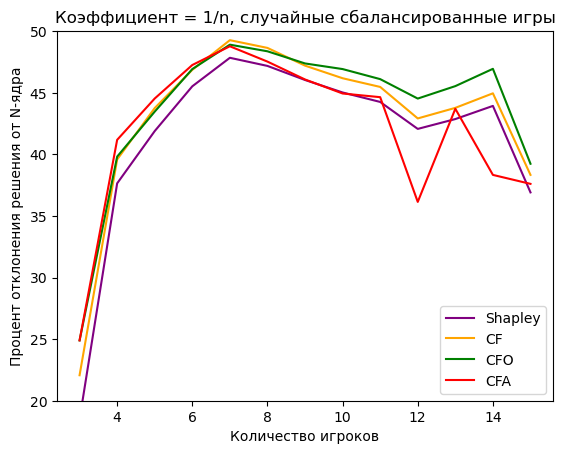

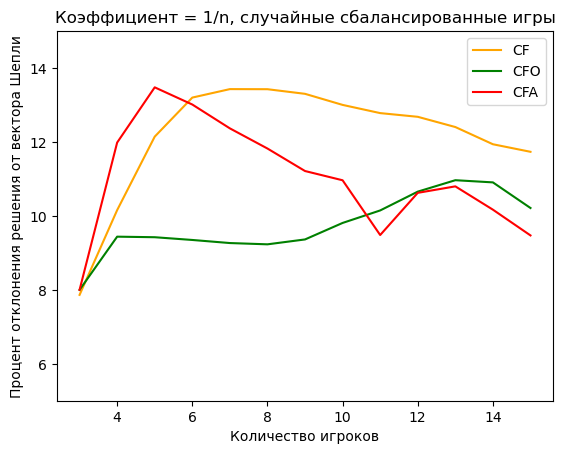

In [ ]:
game_type = 'Balanced'
path = 'local\\results'
distance_path = path
# distance_path = False

print_coef = 'Коэффициент = 1/n'
table_list = {}
for n in range(3, 21):
    coefficient = 1 / n
    compute_path = f'{path}\\compute\\{game_type}\\{n}'
    if distance_path:
        distance_path = f'{path}\\compute_distance\\{game_type}\\{n}'

    add_row(table_list, n, coefficient, compute_path, distance_path)

table = pd.DataFrame(table_list).T


match game_type:
    case "Superadditive":
        game_name = 'супераддитивные сбалансированные игры'
    case "Balanced":
        game_name = 'случайные сбалансированные игры'

fig, ax = plt.subplots()
ax.plot(table.index, table['exc_dt'], label='Проверка эксцессов', color='grey')
ax.plot(table.index, table['mscp_dt'], label='MSCP', color='blue')
ax.plot(table.index, table['shapley_dt'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_dt'], label='CF', color='orange')
ax.plot(table.index, table['cfo_dt'], label='CFO', color='green')
ax.plot(table.index, table['cfa_dt'], label='CFA', color='red')
if distance_path:
    ax.plot(table.index, table['nuc_dt'], label='N-ядро', color='black')
ax.set_ylim(0, 1.5)
ax.set_ylabel('Время работы, сек')
ax.set_xlabel('Количество игроков')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['mscp_dif'], label=r'$\delta$', color='blue')
ax.plot(table.index, table['cf_dif'], label='CF', color='orange')
ax.plot(table.index, table['cfo_dif'], label='CFO', color='green')
ax.plot(table.index, table['cfa_dif'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Превышение min x(N), %')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['shapley_core_hits'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_core_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_core_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_core_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlim(3, 21)
ax.set_title(f'{print_coef}, {game_name}')
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент попаданий в С-ядро')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['cf_vn_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_vn_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_vn_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент гарантий попадания в С-ядро')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

if distance_path:
    fig, ax = plt.subplots()
    ax.plot(table.index, table['nuc_vs_shapley'], label='Shapley', color='purple')
    ax.plot(table.index, table['nuc_vs_cf'], label='CF', color='orange')
    ax.plot(table.index, table['nuc_vs_cfo'], label='CFO', color='green')
    ax.plot(table.index, table['nuc_vs_cfa'], label='CFA', color='red')
    ax.set_ylim(20, 50)
    ax.set_xlabel('Количество игроков')
    ax.set_ylabel('Процент отклонения решения от N-ядра')
    ax.set_title(f'{print_coef}, {game_name}')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(table.index, table['shapley_vs_cf'], label='CF', color='orange')
    ax.plot(table.index, table['shapley_vs_cfo'], label='CFO', color='green')
    ax.plot(table.index, table['shapley_vs_cfa'], label='CFA', color='red')
    ax.set_ylim(5, 15)
    ax.set_xlabel('Количество игроков')
    ax.set_ylabel('Процент отклонения решения от вектора Шепли')
    ax.set_title(f'{print_coef}, {game_name}')
    ax.legend()
    plt.show()

##### 3.1.2 Супераддитивные игры

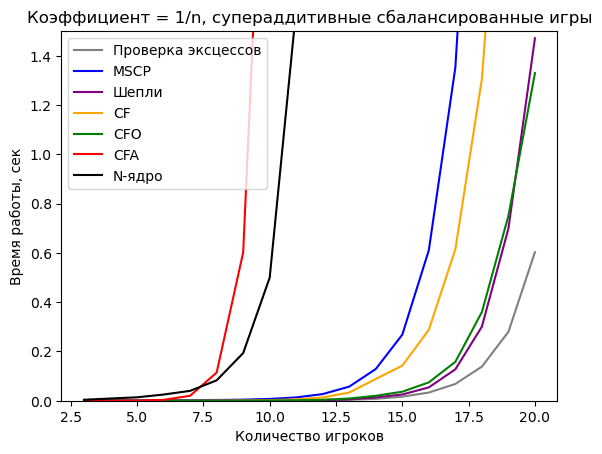

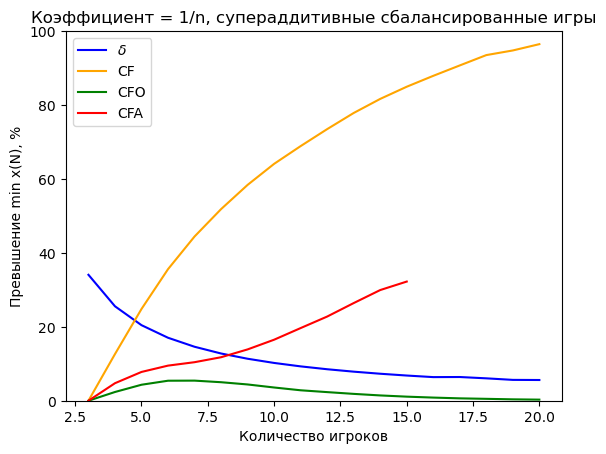

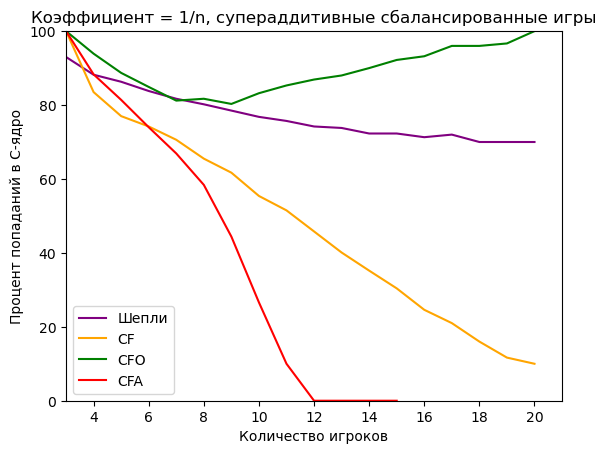

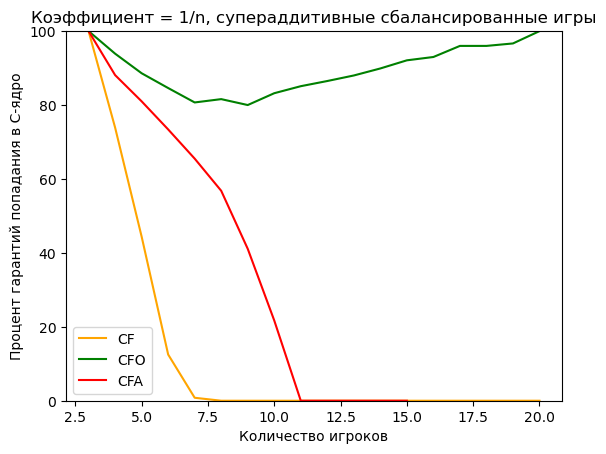

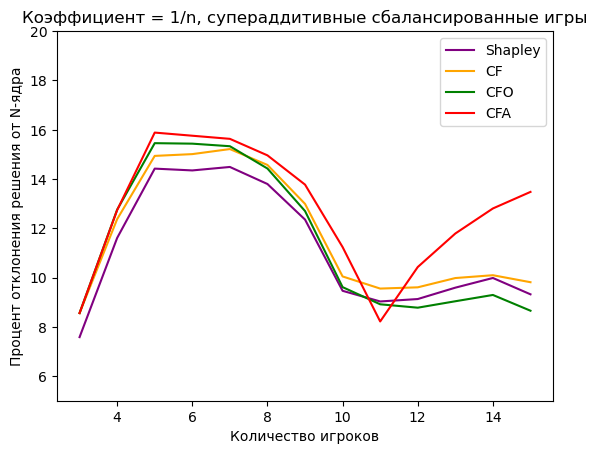

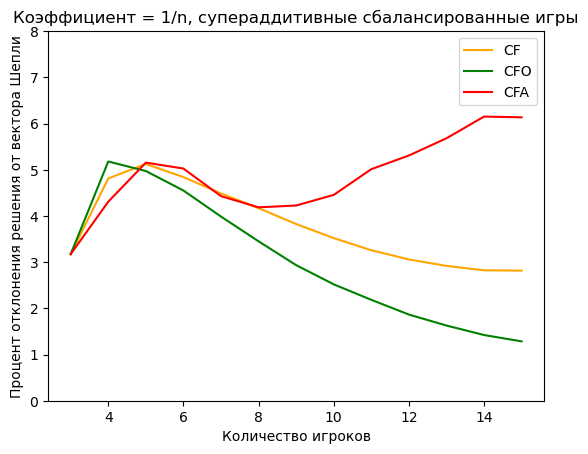

In [ ]:
game_type = 'Superadditive'
path = 'local\\results'
distance_path = path
# distance_path = False

print_coef = 'Коэффициент = 1/n'
table_list = {}
for n in range(3, 21):
    coefficient = 1 / n
    compute_path = f'{path}\\compute\\{game_type}\\{n}'
    if distance_path:
        distance_path = f'{path}\\compute_distance\\{game_type}\\{n}'

    add_row(table_list, n, coefficient, compute_path, distance_path)

table = pd.DataFrame(table_list).T


match game_type:
    case "Superadditive":
        game_name = 'супераддитивные сбалансированные игры'
    case "Balanced":
        game_name = 'случайные сбалансированные игры'

fig, ax = plt.subplots()
ax.plot(table.index, table['exc_dt'], label='Проверка эксцессов', color='grey')
ax.plot(table.index, table['mscp_dt'], label='MSCP', color='blue')
ax.plot(table.index, table['shapley_dt'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_dt'], label='CF', color='orange')
ax.plot(table.index, table['cfo_dt'], label='CFO', color='green')
ax.plot(table.index, table['cfa_dt'], label='CFA', color='red')
if distance_path:
    ax.plot(table.index, table['nuc_dt'], label='N-ядро', color='black')
ax.set_ylim(0, 1.5)
ax.set_ylabel('Время работы, сек')
ax.set_xlabel('Количество игроков')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['mscp_dif'], label=r'$\delta$', color='blue')
ax.plot(table.index, table['cf_dif'], label='CF', color='orange')
ax.plot(table.index, table['cfo_dif'], label='CFO', color='green')
ax.plot(table.index, table['cfa_dif'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Превышение min x(N), %')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['shapley_core_hits'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_core_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_core_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_core_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlim(3, 21)
ax.set_title(f'{print_coef}, {game_name}')
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент попаданий в С-ядро')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['cf_vn_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_vn_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_vn_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент гарантий попадания в С-ядро')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

if distance_path:
    fig, ax = plt.subplots()
    ax.plot(table.index, table['nuc_vs_shapley'], label='Shapley', color='purple')
    ax.plot(table.index, table['nuc_vs_cf'], label='CF', color='orange')
    ax.plot(table.index, table['nuc_vs_cfo'], label='CFO', color='green')
    ax.plot(table.index, table['nuc_vs_cfa'], label='CFA', color='red')
    ax.set_ylim(5, 20)
    ax.set_xlabel('Количество игроков')
    ax.set_ylabel('Процент отклонения решения от N-ядра')
    ax.set_title(f'{print_coef}, {game_name}')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(table.index, table['shapley_vs_cf'], label='CF', color='orange')
    ax.plot(table.index, table['shapley_vs_cfo'], label='CFO', color='green')
    ax.plot(table.index, table['shapley_vs_cfa'], label='CFA', color='red')
    ax.set_ylim(0, 8)
    ax.set_xlabel('Количество игроков')
    ax.set_ylabel('Процент отклонения решения от вектора Шепли')
    ax.set_title(f'{print_coef}, {game_name}')
    ax.legend()
    plt.show()

#### 3.2 Альтернативные коэффициенты

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

def add_row_coef(table_list, n, coefficient, compute_path):
    try:
        with np.errstate(divide='ignore', invalid='ignore'):
            series = pd.read_excel(f'{compute_path}\\{coefficient}.xlsx', sheet_name='series').iloc[0]

            table_list[n] = {
                'shapley_core_hits': series['shapley_core_hits'] / series['shapley_count'] * 100,
                'cf_core_hits': series['cf_core_hits'] / series['cf_count'] * 100,
                'cfo_core_hits': series['cfo_core_hits'] / series['cfo_count'] * 100,
                'cfa_core_hits': series['cfa_core_hits'] / series['cfa_count'] * 100,

                'cf_vn_hits': series['cf_vn_hits'] / series['cf_count'] * 100,
                'cfo_vn_hits': series['cfo_vn_hits'] / series['cfo_count'] * 100,
                'cfa_vn_hits': series['cfa_vn_hits'] / series['cfa_count'] * 100,
            }

    except Exception:
        if os.path.exists(f'{compute_path}\\{coefficient}.xlsx'):
            raise Exception(f'Повреждён файл: {compute_path}\\{coefficient}.xlsx')

##### 3.2.1 Случайные игры

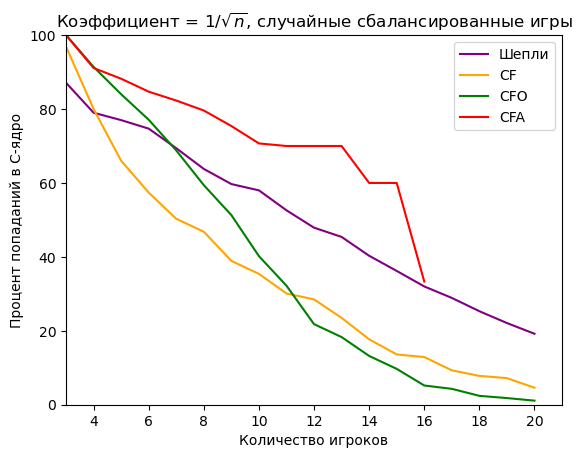

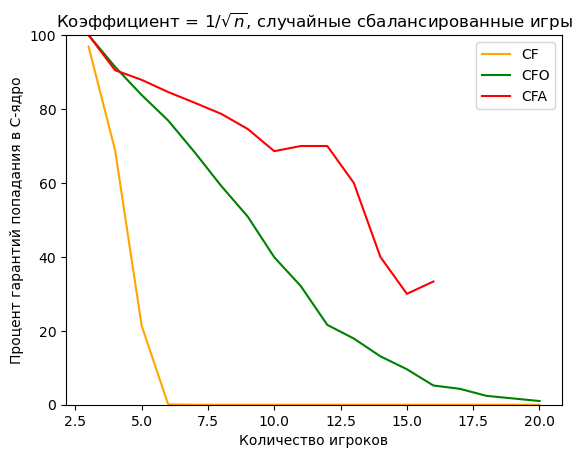

In [ ]:
game_type = 'Balanced'
path = 'local\\results'

print_coef = r'Коэффициент = 1/$\sqrt{n}$'
table_list = {}
for n in range(3, 21):
    coefficient = 1 / np.sqrt(n)
    compute_path = f'{path}\\compute\\{game_type}\\{n}'

    add_row_coef(table_list, n, coefficient, compute_path)

table = pd.DataFrame(table_list).T


match game_type:
    case "Superadditive":
        game_name = 'супераддитивные сбалансированные игры'
    case "Balanced":
        game_name = 'случайные сбалансированные игры'

fig, ax = plt.subplots()
ax.plot(table.index, table['shapley_core_hits'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_core_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_core_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_core_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlim(3, 21)
ax.set_title(f'{print_coef}, {game_name}')
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент попаданий в С-ядро')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['cf_vn_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_vn_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_vn_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент гарантий попадания в С-ядро')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()

##### 3.2.2 Супераддитивные игры

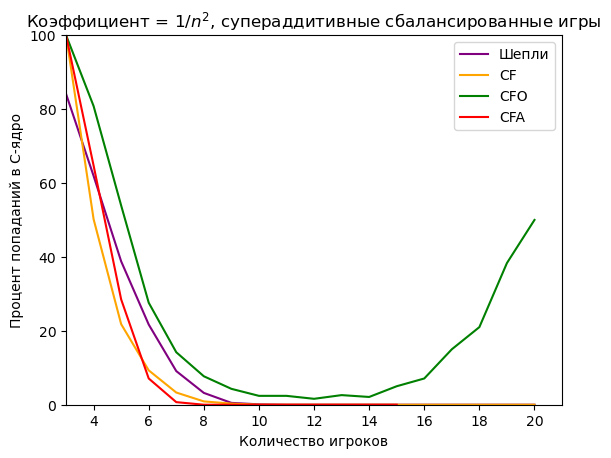

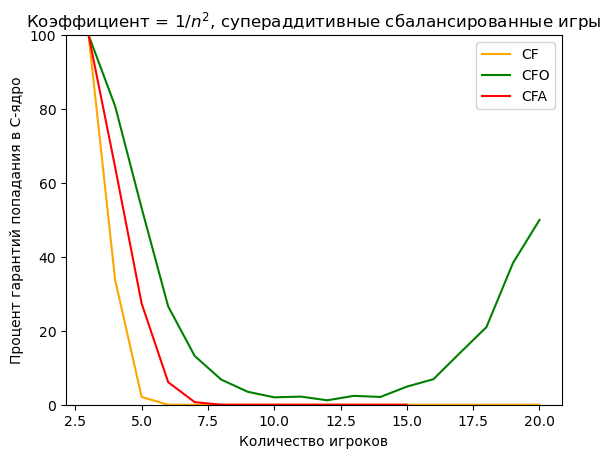

In [ ]:
game_type = 'Superadditive'
path = 'local\\results'

print_coef = r'Коэффициент = 1/$n^2$'
table_list = {}
for n in range(3, 21):
    coefficient = 1 / n**2
    compute_path = f'{path}\\compute\\{game_type}\\{n}'

    add_row_coef(table_list, n, coefficient, compute_path)

table = pd.DataFrame(table_list).T


match game_type:
    case "Superadditive":
        game_name = 'супераддитивные сбалансированные игры'
    case "Balanced":
        game_name = 'случайные сбалансированные игры'

fig, ax = plt.subplots()
ax.plot(table.index, table['shapley_core_hits'], label='Шепли', color='purple')
ax.plot(table.index, table['cf_core_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_core_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_core_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlim(3, 21)
ax.set_title(f'{print_coef}, {game_name}')
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент попаданий в С-ядро')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(table.index, table['cf_vn_hits'], label='CF', color='orange')
ax.plot(table.index, table['cfo_vn_hits'], label='CFO', color='green')
ax.plot(table.index, table['cfa_vn_hits'], label='CFA', color='red')
ax.set_ylim(0, 100)
ax.set_xlabel('Количество игроков')
ax.set_ylabel('Процент гарантий попадания в С-ядро')
ax.set_title(f'{print_coef}, {game_name}')
ax.legend()
plt.show()